# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Creating directory: output/draft3_run//alpha_search...Directory exists. Skipping.
Number of alphas: 3
Testing alpha values: [24, 32, 36]
Running for genes: ['DSE1', 'DSE2']
Searching replicate 1 alphas: DSE1...
24,32,36,
00:02:12.820
Searching replicate 1 alphas: DSE2...
24,32,36,
00:04:33.844
Searching replicate 2 alphas: DSE1...
24,32,36,
00:06:42.794
Searching replicate 2 alphas: DSE2...
24,32,36,
00:08:49.692
Results saved to output/draft3_run//alpha_search


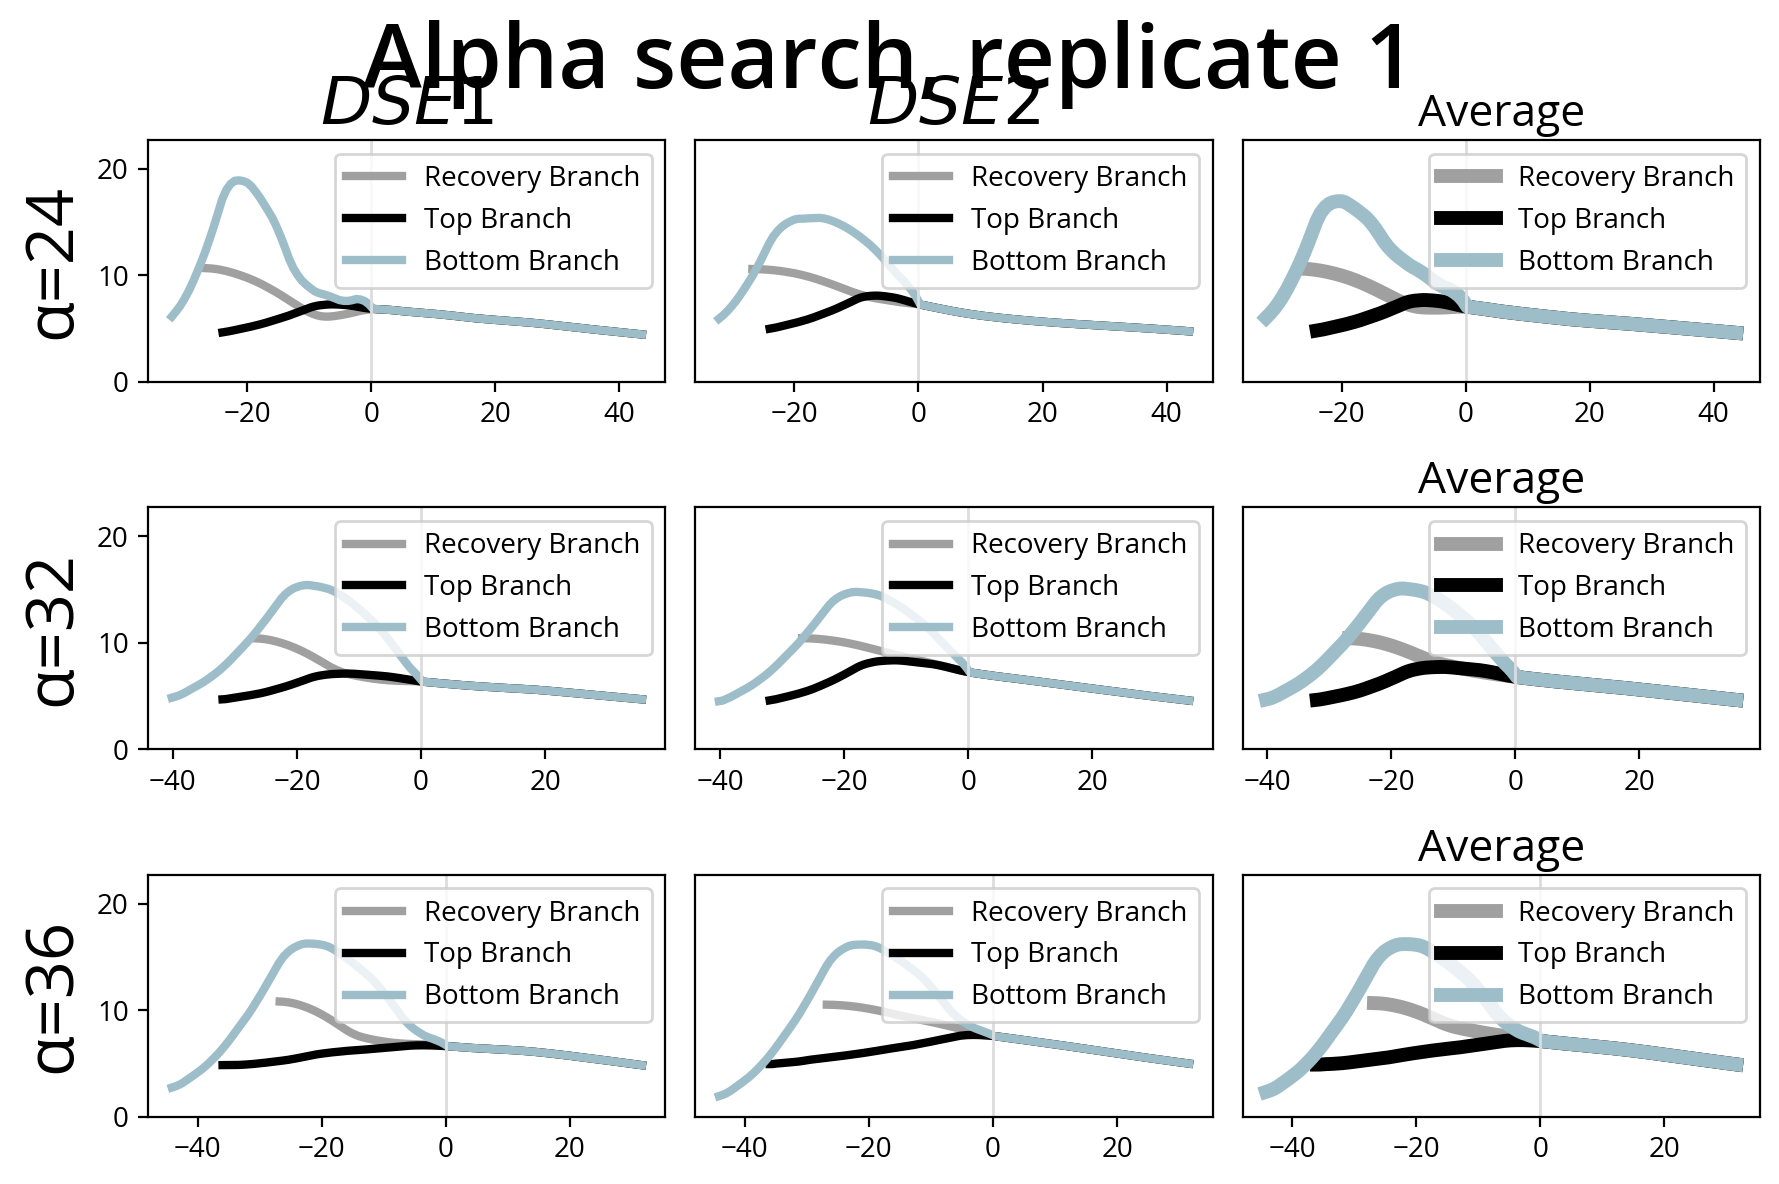

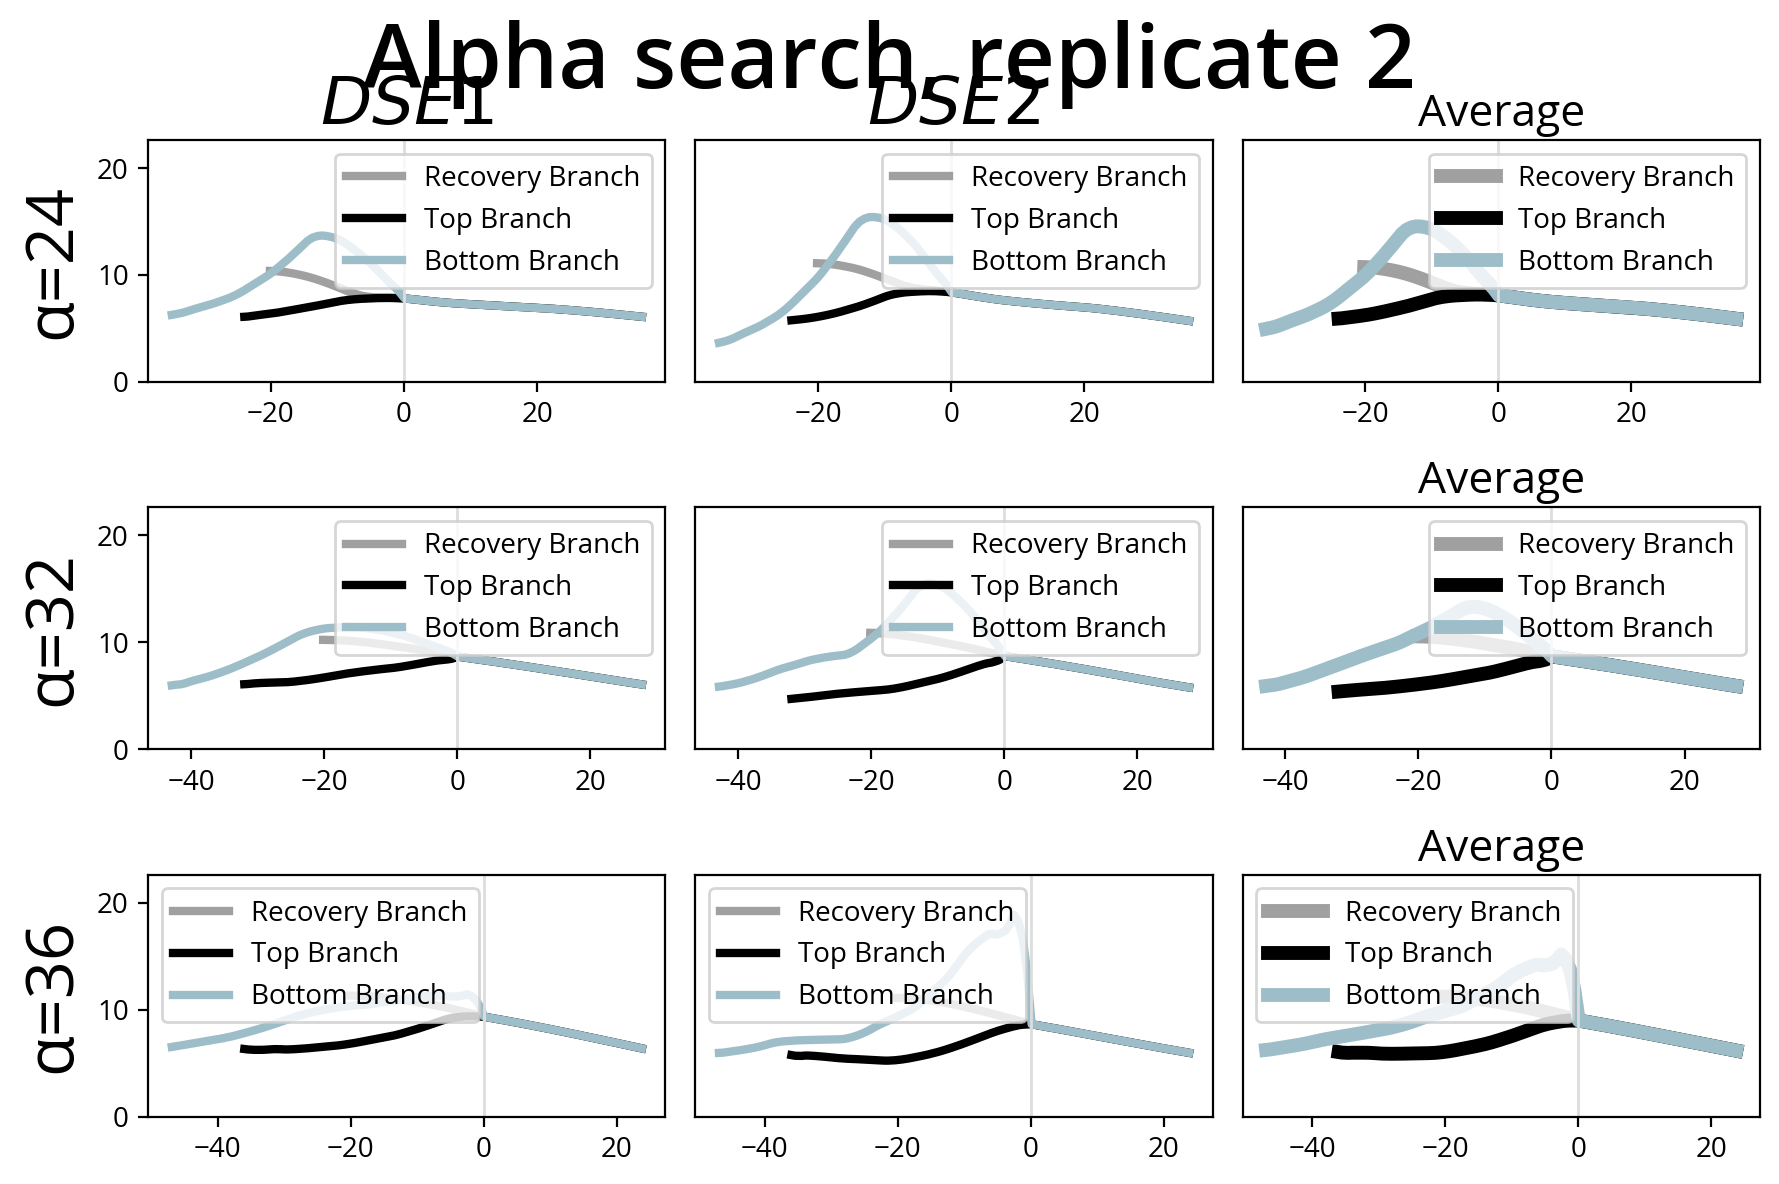

In [2117]:
from src.alpha_search import FindAlphaSweepDS

finder = FindAlphaSweepDS(output_directory='output/draft3_run/', 
    gene_names=['DSE1', 'DSE2'])
finder.run_alpha_sweep(alphas=[24, 32, 36])
finder.plot_and_save_results(save=False)


In [2242]:
finder.runner.config1.modify_alpha(32)
finder.runner.deconvolve_gene_find_gamma('CLB2', replicate=1, verbose=True)

	Base error (γ=0):	rn: 0.240752	sn: 11565.038295
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.25279
			Absolute (e0 + 0.04): 0.280752
			Chosen: 0.252790
		Right:
			Relative (4.00 * e0): 0.963008
			Absolute (e0 + 11.32): 11.5608
			Chosen: 11.560752
	Searching for left boundary gamma...
		γ: 0.5005	rn: 9.3338	sn: 70.8143
		γ: 0.25075	rn: 7.0482	sn: 76.8992
		γ: 0.125875	rn: 6.1085	sn: 82.4260
		γ: 0.0634375	rn: 5.3194	sn: 92.4615
		γ: 0.0322187	rn: 2.6139	sn: 150.2564
		γ: 0.0166094	rn: 1.6132	sn: 192.6925
		γ: 0.00880469	rn: 1.1203	sn: 234.0861
		γ: 0.00490234	rn: 0.9093	sn: 264.9021
		γ: 0.00295117	rn: 0.8236	sn: 286.7144
		γ: 0.00197559	rn: 0.7842	sn: 303.2047
		γ: 0.00148779	rn: 0.7536	sn: 320.3048
		γ: 0.0012439	rn: 0.7404	sn: 330.2956
		γ: 0.00112195	rn: 0.7174	sn: 350.2880
		γ: 0.00106097	rn: 0.6976	sn: 368.3887
		γ: 0.00103049	rn: 0.6904	sn: 375.2300
		γ: 0.00101524	rn: 0.6867	sn: 378.8531
		γ: 0.00100762	rn: 0.6847	sn: 380.8652
		γ: 0.00100381	rn: 0.6843	sn: 381.240

In [2243]:
finder.runner.expression_find_gamma.gamma_optimizer.gamma_left,\
finder.runner.expression_find_gamma.gamma_optimizer.gamma_right

(0.0010004763603210448, 0.6582511705155337)

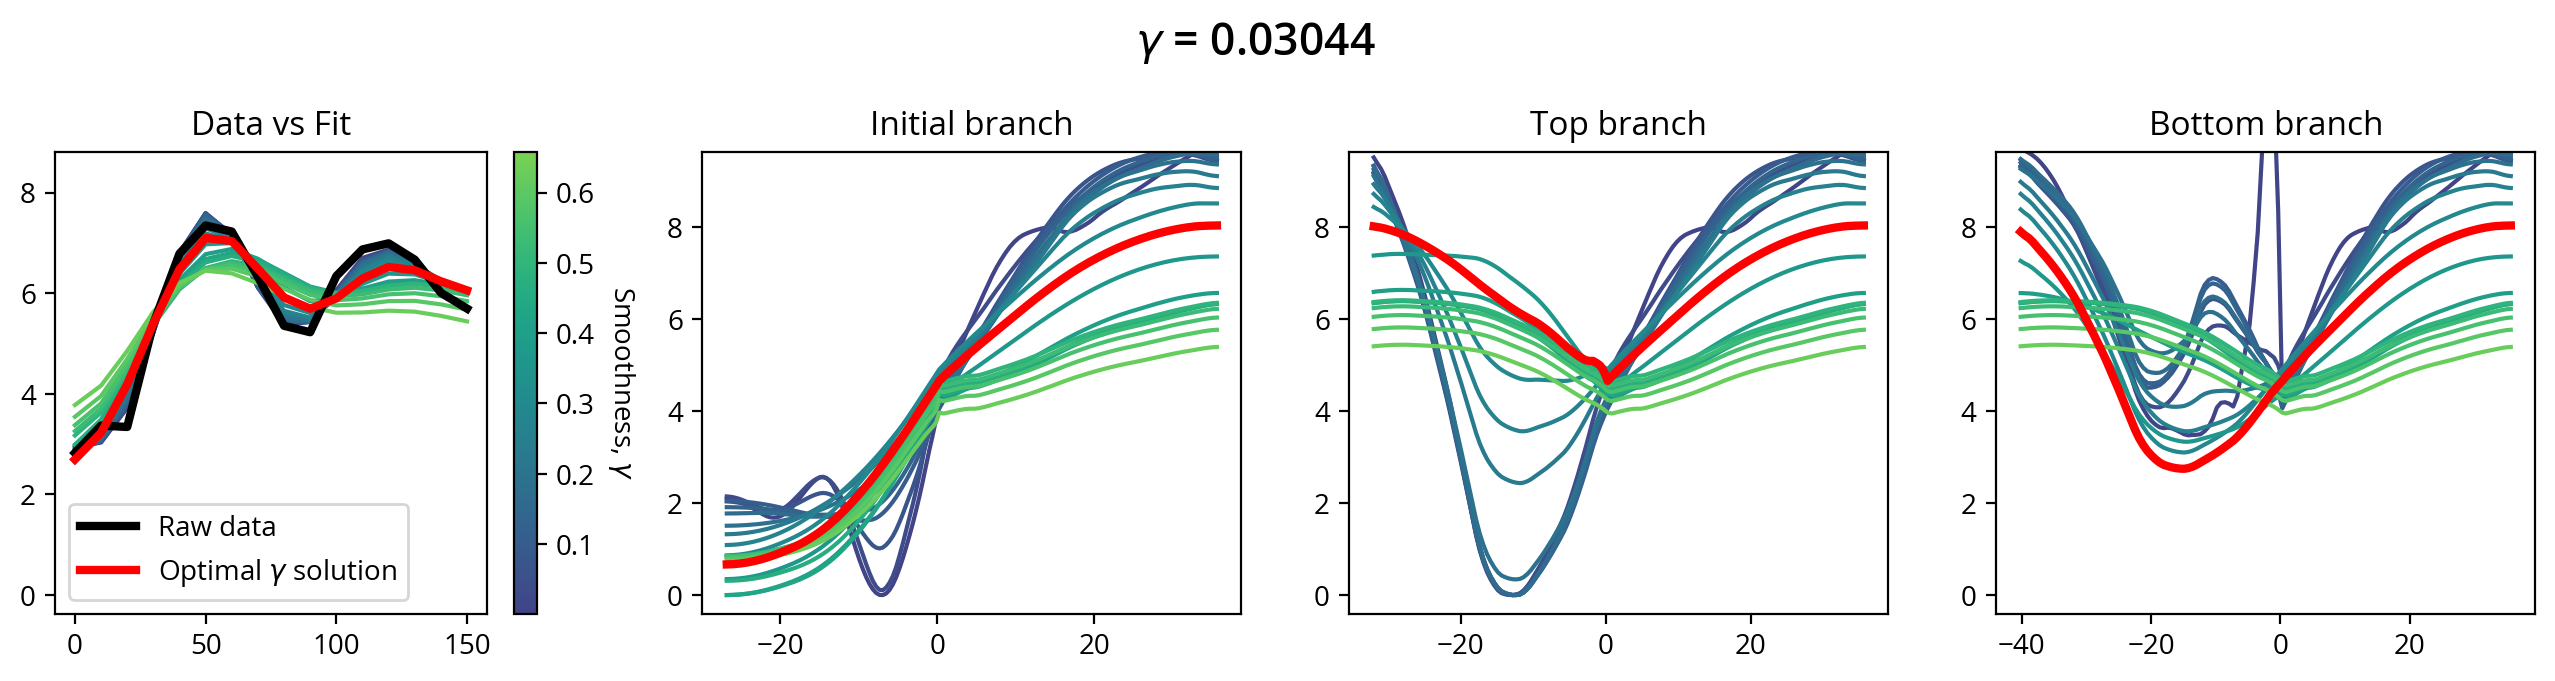

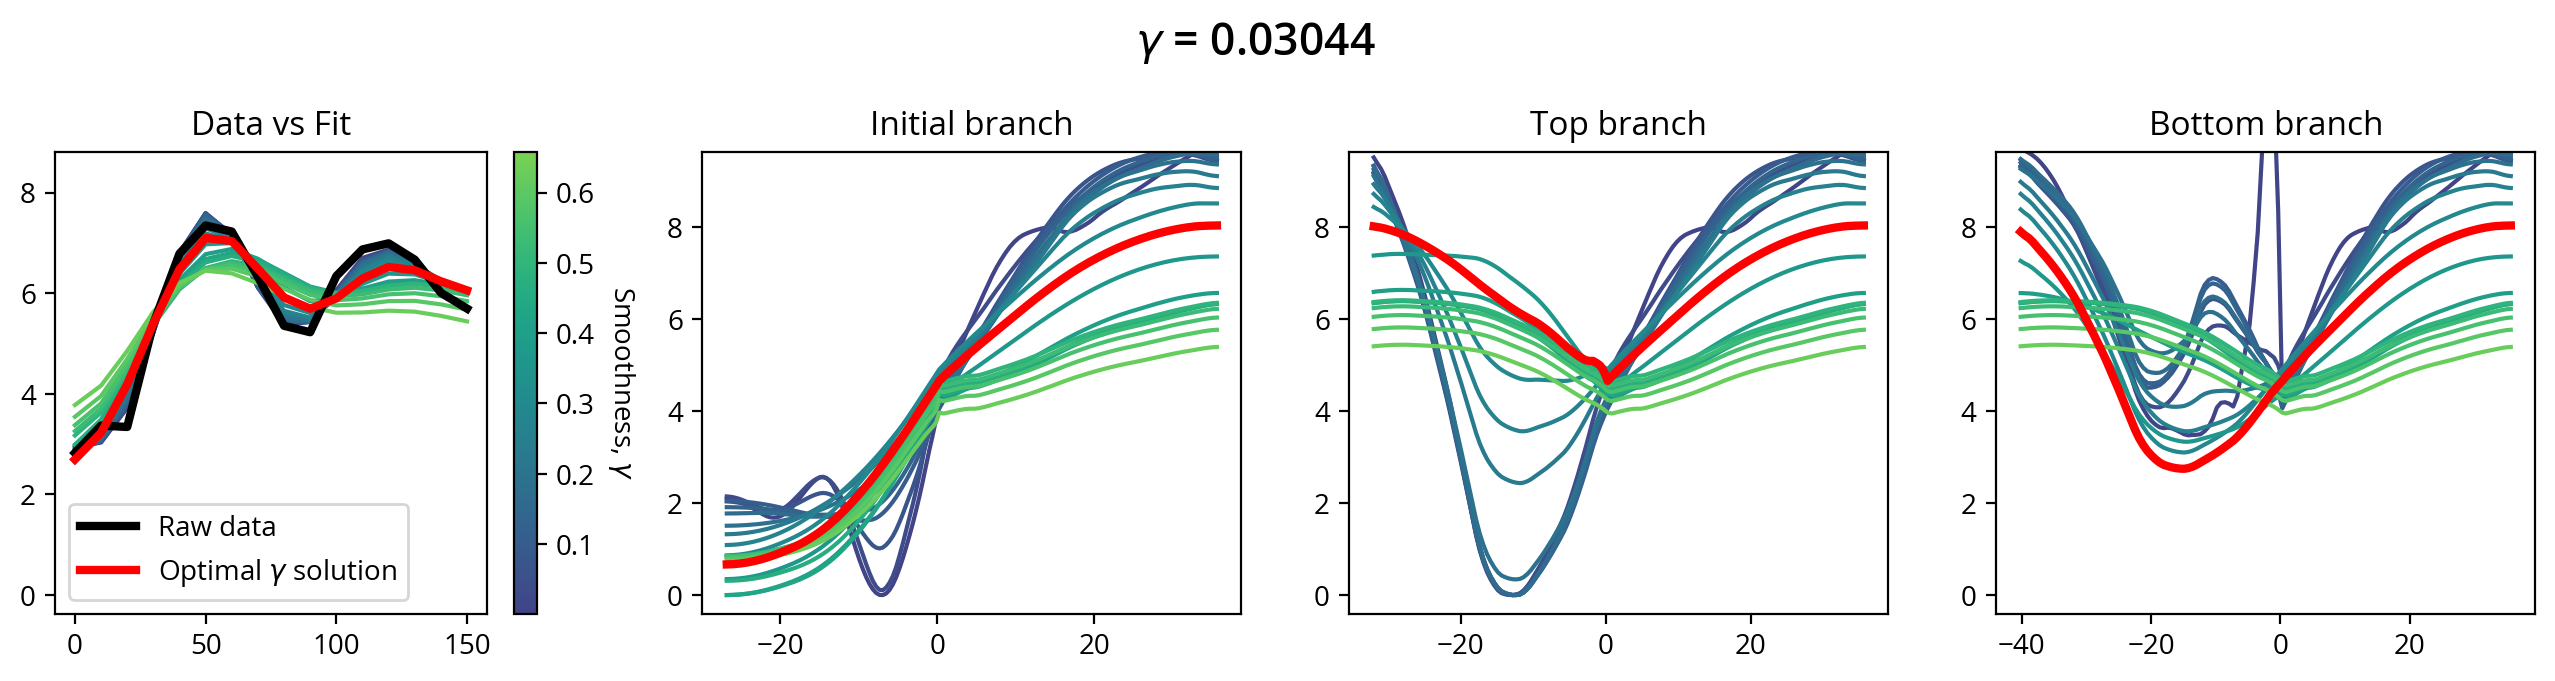

In [2244]:
finder.runner.expression_find_gamma.plot_gamma_sweep()

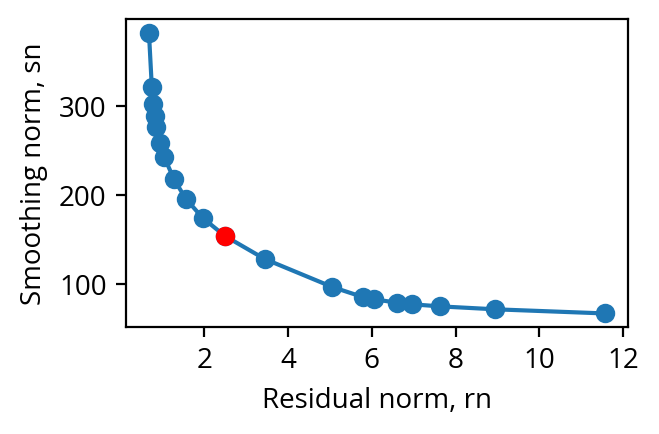

In [2245]:
finder.runner.expression_find_gamma.gamma_optimizer.plot_elbow()

In [2250]:
finder.runner.expression_find_gamma.deconvolution_solver.gamma = 0.03
finder.runner.expression_find_gamma.deconvolution_solver.deconvolve()

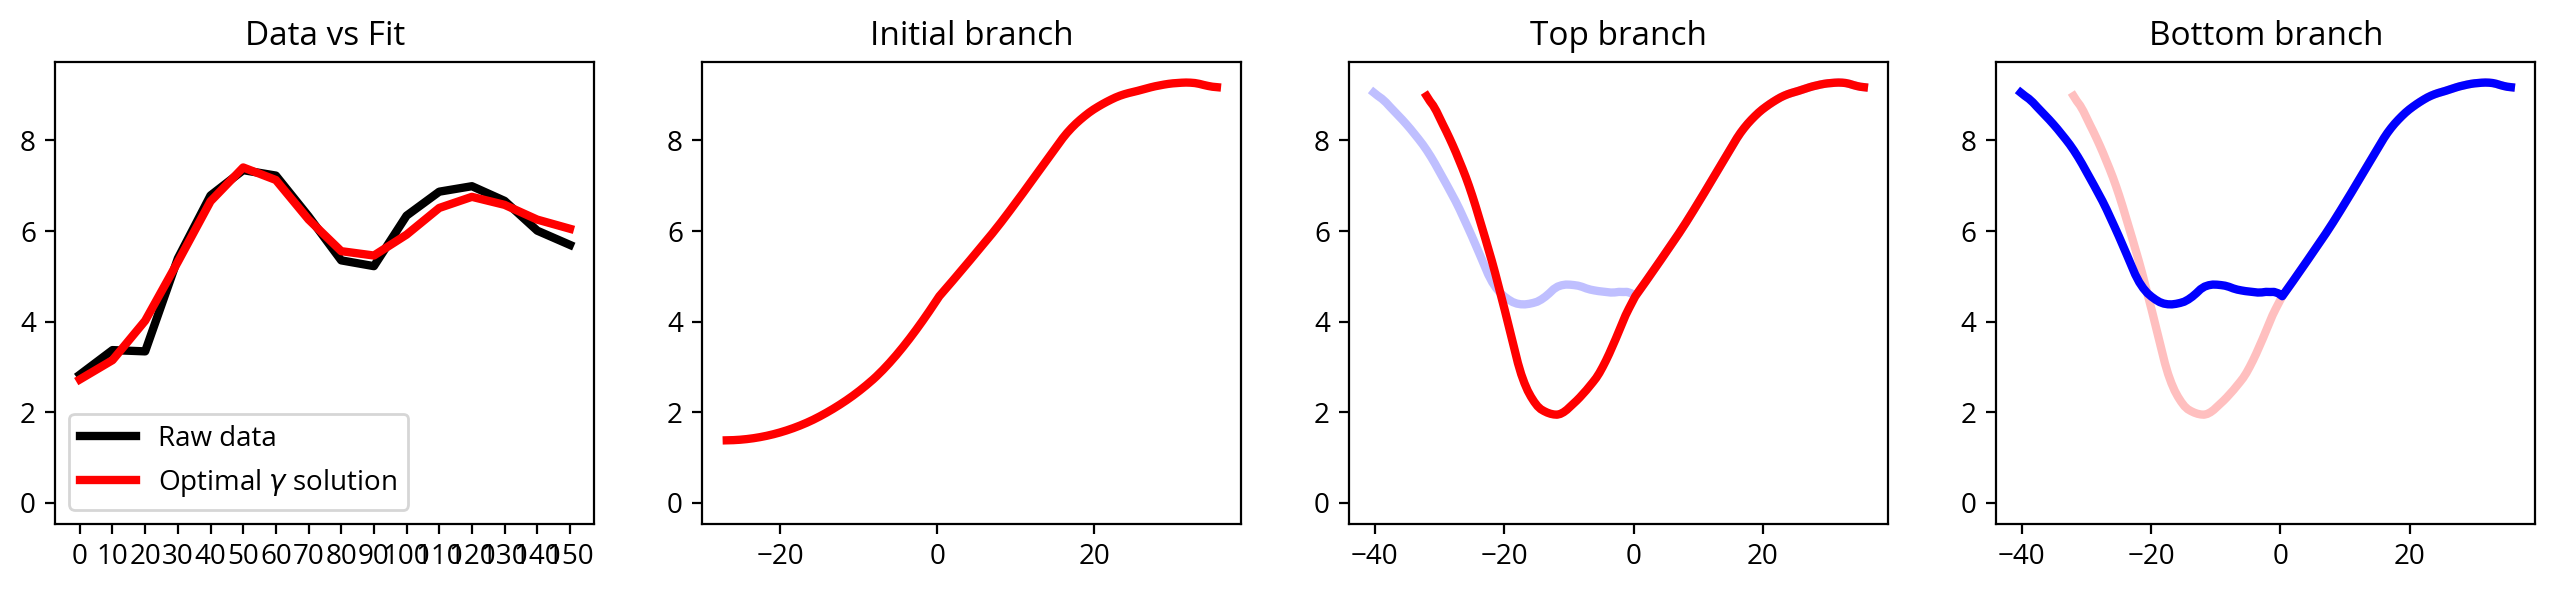

In [2249]:
finder.runner.expression_find_gamma.deconvolution_solver.plot_fit(True)

In [2248]:
finder.runner.expression_find_gamma.deconvolution_solver.rn

array(1.21240196)